2.1

#1.Transform Definition:
    It defines a transform that converts the images to tensors and normalizes them. The transforms.ToTensor() converts PIL images or numpy arrays to PyTorch tensors, and transforms.Normalize() normalizes the tensor with a mean and standard deviation.

#2.Training Data Loading:
    It downloads the FashionMNIST training dataset, applies the defined transform, and creates a DataLoader for batching the data with a batch size of 64. The shuffle=True parameter shuffles the training data at the beginning of each epoch.

#3.Test Data Loading:
    Similarly, it downloads the FashionMNIST test dataset, applies the same transform, and creates a DataLoader for batching the test data with the same batch size and shuffle configuration.

#4.Print Dataset Sizes:
    It prints the sizes of the training and test datasets.

In [19]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load Fashion MNIST datasets
train_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
test_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)

# Set batch size for data loaders
batch_size = 64

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print the size of the datasets
print("Training Data Size:", len(train_loader.dataset))
print("Test Data Size:", len(test_loader.dataset))


Training Data Size: 60000
Test Data Size: 10000


2.2

#1
    import torch: Import the PyTorch library.
    from torchvision import datasets, transforms: Import the necessary modules from torchvision, which provides datasets and image transformation utilities.
    from sklearn.model_selection import train_test_split: Import the train_test_split function from scikit-learn to split the dataset.

#2
    Define a transformation (transform) using transforms.Compose that includes converting the images to PyTorch tensors (transforms.ToTensor()) and normalizing the pixel values to a range between -1 and 1 (transforms.Normalize((0.5,), (0.5,))).

#3
    Download the Fashion MNIST dataset using the datasets.FashionMNIST class from torchvision. Specify the root directory for storing the dataset, that it is the training set (train=True), and apply the defined transform.

#4
    Normalize the pixel values of the images to the range [0, 1] by dividing each pixel value by 255.0. Convert the data to float and unsqueeze to add a channel dimension.
    Normalize the pixel values of the images to a range between 0 and 1.why?

            1.Numerical Stability: Normalizing pixel values to a standardized range, such as [0, 1], helps in maintaining numerical stability during computations. Deep learning models often involve weight parameters that are updated through optimization algorithms. Having input values in a consistent and bounded range can prevent numerical instability issues during training.

            2.Faster Convergence: Normalization can lead to faster convergence during training. Many optimization algorithms, like gradient descent, converge faster when the input features are within a similar scale. This helps in reducing the number of iterations required for the model to learn meaningful patterns in the data.

            3.Avoiding Saturation of Activation Functions: Activation functions, such as sigmoid or tanh, can saturate if their input values are too large or too small. Normalizing pixel values to [0, 1] ensures that the input to activation functions is within a reasonable range, preventing saturation and helping the model learn more effectively.

            4.Facilitating Learning: Normalizing pixel values helps the model focus on learning relevant patterns in the data by reducing the impact of irrelevant variations in pixel intensities. This is particularly important in computer vision tasks where the lighting conditions or contrast in images may vary.

            5.Consistent Input Scaling: Normalizing to a standardized range makes it easier to compare and combine different datasets. It ensures that the input data have a consistent scale, which is important when working with diverse datasets.

            6.Compatibility with Certain Activation Functions: Some activation functions, like ReLU (Rectified Linear Unit), work well when the input is non-negative. Normalizing pixel values to [0, 1] ensures that the input to ReLU is within this non-negative range.

            7.Preventing Gradient Explosion or Vanishing: Normalization can help mitigate issues related to exploding or vanishing gradients, especially in deep networks. This is because weight updates are proportional to the gradients, and having input values within a reasonable range can help control the magnitude of gradients.


#5
    Use train_test_split to split the dataset into training and testing sets. The test_size=0.2 argument specifies that 20% of the data will be used for testing. The stratify parameter ensures that the class distribution is maintained during the split.
    Use train_test_split to split the dataset into training and testing sets.why?

        1.Evaluation of Model Generalization: The primary purpose of splitting a dataset into training and testing sets is to evaluate how well the model generalizes to new, unseen data. The training set is used to train the model, while the testing set, which the model has never seen during training, is used to assess its performance on data it hasn't been exposed to before.

        2.Model Validation: During the development of a machine learning model, it's essential to validate the model's performance on a set of data that wasn't used for training. This helps identify whether the model has learned patterns that are specific to the training data (overfitting) or if it can generalize well to new data.

        3.Hyperparameter Tuning: The testing set is often used for hyperparameter tuning. By trying different hyperparameter configurations and evaluating their performance on the testing set, you can select the set of hyperparameters that leads to the best generalization performance.

        4.Avoiding Overfitting: If the model is trained and evaluated on the same dataset, there's a risk of overfitting. Overfitting occurs when the model memorizes the training data rather than learning the underlying patterns. Separating the dataset into training and testing sets helps detect overfitting and ensures that the model's performance is assessed on unseen data.

        5.Assessing Performance Metrics: Testing on a separate dataset allows for a more accurate assessment of performance metrics, such as accuracy, precision, recall, and F1 score. These metrics provide insights into how well the model performs on real-world, out-of-sample data.

        6.Model Deployment: When deploying a machine learning model in a real-world scenario, it will encounter new, unseen data. The testing set simulates this scenario, helping ensure that the model performs well in practice.

#6
    Further split the test set into testing and validation sets, with each set containing 50% of the original test data.

#7
    Create PyTorch TensorDataset objects for the training, testing, and validation sets, associating the data tensors with their respective label tensors.

    Converting data and labels into PyTorch tensors is necessary to work with them efficiently within the PyTorch framework. PyTorch tensors are the fundamental data structure used for storing and manipulating numerical data, and they enable automatic differentiation for training neural networks. Here's why creating PyTorch tensors is important:
        
        1.PyTorch Operations: PyTorch tensors provide a unified interface for numerical operations and transformations, making it easy to perform various mathematical operations, manipulations, and transformations on the data. This is crucial for building and training deep learning models.

        2.Automatic Differentiation: PyTorch tensors enable automatic differentiation through the autograd module. This functionality is crucial for backpropagation during the training of neural networks. It allows the computation of gradients with respect to the model parameters, which is necessary for optimizing the model using gradient descent or its variants.

        3.GPU Acceleration: PyTorch tensors can be easily moved to GPU devices, facilitating accelerated computations. This is particularly important for training deep learning models on large datasets or with complex architectures, as GPUs can significantly speed up the training process.

        4.Integration with PyTorch Ecosystem: PyTorch tensors seamlessly integrate with other PyTorch components, such as modules, optimizers, and loss functions. Using PyTorch tensors ensures compatibility and ease of use with the broader PyTorch ecosystem.

#8
    Create PyTorch data loaders for the training, testing, and validation sets, specifying a batch size of 64 for each. The shuffle parameter is set to True for the training set to shuffle the data during each epoch. shuffle is set to False for testing and validation sets.

    shuffle is set to False for testing and validation sets.why?
        Setting shuffle to False for testing and validation sets is a common practice in machine learning. The idea behind this choice is to ensure reproducibility and consistency in evaluation. Here's the rationale:
        
            Testing Set (or Evaluation Set): When evaluating a model on a testing set, you want to ensure that the evaluation is consistent each time you run it. Shuffling the testing set would introduce randomness, potentially leading to different evaluation results for the same model. By keeping the order fixed (not shuffling), you can obtain reliable and reproducible evaluation metrics.

            Validation Set: Similar to the testing set, the validation set is used during the training phase to tune hyperparameters and monitor the model's performance. Consistency is key during this process, and fixing the order of the validation set helps achieve that consistency.



In [20]:
#1
import torch
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

#2 Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

#3 Download the Fashion MNIST dataset
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

#4 Normalize pixel values to a range between 0 and 1
normalized_data = (dataset.data.float() / 255.0).unsqueeze(1)  # Normalize and add channel dimension

#5 Split the dataset into training, testing, and validation sets
train_data, test_data, train_labels, test_labels = train_test_split(
    normalized_data, dataset.targets, test_size=0.2, random_state=42, stratify=dataset.targets)

#6 Further split the test set into test and validation sets
test_data, val_data, test_labels, val_labels = train_test_split(
    test_data, test_labels, test_size=0.5, random_state=42, stratify=test_labels)

#7 Create PyTorch tensors for the data and labels
train_dataset = torch.utils.data.TensorDataset(train_data, train_labels)
test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
val_dataset = torch.utils.data.TensorDataset(val_data, val_labels)

#8 Create data loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)

print("Training Data Size:", len(train_loader.dataset))
print("Validation Data Size:", len(val_loader.dataset))
print("Test Data Size:", len(test_loader.dataset))


Training Data Size: 48000
Validation Data Size: 6000
Test Data Size: 6000


2.3

1. Convolutional Layers:
    Convolutional layers are designed to capture local patterns in the input data. They use small filters (kernels) to slide over the input image and learn features like edges, textures, and simple patterns.

     self.conv1:
        The first convolutional layer with 32 filters, each having a 3x3 kernel. It takes a single-channel input (assuming grayscale images) and produces 32 feature maps.

    self.conv2: 
        The second convolutional layer with 64 filters, again using a 3x3 kernel. It takes the 32 feature maps from the previous layer as input, producing 64 feature maps.
        
Fully Connected Layers:
     Fully connected layers take the features learned by convolutional layers and use them to make final predictions. These layers connect every neuron to every neuron in the previous and subsequent layers.

    self.fc1: The first fully connected layer with 128 neurons. The input size is determined by the flattened output from the previous layers (64 * 7 * 7), and it produces a feature vector with 128 elements.

    self.fc2: The final fully connected layer with the specified number of output classes (assuming a classification task). This layer produces the final output scores for each class.

self.pool1: Performs max pooling over a 2x2 window, reducing spatial dimensions by half.

Input Shape:

The architecture assumes grayscale images (single-channel) with variable dimensions (height x width). The number of input channels is set to 1 in the first convolutional layer.

Output Layer:
The output layer (self.fc2) has a number of neurons equal to the number of classes in the classification task. It produces raw scores or logits for each class, and the final predictions are often obtained using a softmax activation during training.

Overall Design:
The convolutional layers capture hierarchical features from the input images.
The max-pooling layers downsample the spatial dimensions, reducing the computational load and providing translational invariance.
The fully connected layers combine these features for making final predictions.

Convolutional Layers:

conv1: 32 filters, kernel size 3x3, input channels 1 (for grayscale), output channels 32.

relu1: ReLU activation function after the first convolution.

pool1: Max pooling with a 2x2 kernel and stride 2.

conv2: 64 filters, kernel size 3x3, input channels 32, output channels 64.

relu2: ReLU activation function after the second convolution.

pool2: Max pooling with a 2x2 kernel and stride 2.

Fully Connected Layers:

flatten: Flatten the output from the convolutional layers.
fc1: Fully connected layer with 64 * 7 * 7 input features (adjust based on your image dimensions) and 128 output features.
relu3: ReLU activation function after the first fully connected layer.
fc2: Fully connected layer with 128 input features and the specified number of output classes.

In [21]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # Adjust input size based on your image dimensions
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Convolutional layers
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        # Flatten the output for the fully connected layers
        x = self.flatten(x)

        # Fully connected layers
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)

        return x

# Create an instance of the SimpleCNN model
model = SimpleCNN(num_classes=10)


2.4

Loss Function (criterion):

    For a classification task, nn.CrossEntropyLoss() is commonly used. It combines a softmax activation and a negative log-likelihood loss. It is suitable when the model is outputting raw scores/logits for each class.

Optimizer (optimizer):

    optim.Adam(model.parameters(), lr=0.001) selects the Adam optimizer with a learning rate of 0.001. Adam is a popular optimization algorithm that adapts the learning rates for each parameter individually.

Metric for Evaluation (accuracy):

    Accuracy is a common metric for classification tasks. The accuracy function calculates the ratio of correctly predicted samples to the total number of samples. 


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

# Instantiate the model
model = SimpleCNN(num_classes=10)

# Loss Function: CrossEntropyLoss for classification tasks
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Metric for Evaluation: Accuracy
def accuracy(output, target):
    _, predicted = torch.max(output, 1)
    correct = (predicted == target).sum().item()
    total = target.size(0)
    return correct / total


# Print the model architecture
print(model)



SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


2.5

Training Loop:
    Forward Pass: Pass a batch of training data through the model to obtain predictions.
    Calculate Loss: Compute the loss between the model predictions and the ground truth labels using the chosen loss function.
    Backward Pass (Backpropagation): Propagate the gradients backward through the network and update the model parameters using the optimizer.
    Monitor Training Loss: Keep track of the training loss to understand how well the model is learning.

Validation Loop:
    Evaluate on Validation Set: Periodically evaluate the model on a validation set to monitor its performance on unseen data.
    Adjust Hyperparameters: Make adjustments to hyperparameters (e.g., learning rate, regularization) based on validation performance to improve generalization.

Monitoring and Adjustments:
    Learning Curves: Plot learning curves (training loss, validation loss, and accuracy) to visualize the model's performance over epochs.
    Early Stopping: Implement early stopping to halt training if the model's performance on the validation set plateaus or degrades.

Model Evaluation:

Test Set Evaluation: After training, evaluate the final model on a held-out test set to assess its generalization performance.


#1
The training loop iterates over the specified number of epochs. The model is set to training mode, and running_loss is initialized.

#2
This inner loop iterates over batches in the training data. It performs a forward pass, computes the loss, performs a backward pass to compute gradients, and updates the model's weights using the optimizer.

#3
The average training loss for the epoch is calculated.

#4
The model is set to evaluation mode, and a validation loop is performed. The accuracy on the validation set is calculated.

#5
The validation accuracy for the epoch is calculated and printed.

Epoch [1/10]: Indicates that the model is currently in the first epoch out of a total of 10 epochs.

Loss:Represents the average training loss for the current epoch. This value is computed by taking the sum of the losses for all mini-batches in the training set and dividing it by the total number of mini-batches.

Validation Accuracy: Denotes the accuracy of the model on the validation set for the current epoch. It is calculated as the number of correctly predicted samples divided by the total number of samples in the validation set.

Training Loss: The training loss ideally should decrease over epochs, indicating that the model is learning and adjusting its parameters to fit the training data better.

Validation Accuracy: This metric helps you understand how well the model generalizes to unseen data. It's crucial to monitor this value to detect potential overfitting or underfitting.

In [24]:
# Set the number of training epochs
num_epochs = 10

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    total_samples = 0
    correct_samples = 0

    for inputs, labels in train_loader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_samples += labels.size(0)
        correct_samples += (predicted == labels).sum().item()

    # Calculate average loss and accuracy for the epoch
    average_loss = running_loss / total_samples
    accuracy_epoch = correct_samples / total_samples * 100

    # Print statistics for the epoch
    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {average_loss:.4f}, Accuracy: {accuracy_epoch:.2f}%')

# After training, you can evaluate the model on the test set if needed
model.eval()
with torch.no_grad():
    test_correct = 0
    test_total = 0

    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

    test_accuracy = test_correct / test_total * 100
    print(f'Test Accuracy: {test_accuracy:.2f}%')

Epoch [1/10], Loss: 0.0909, Accuracy: 96.61%
Epoch [2/10], Loss: 0.0786, Accuracy: 97.12%
Epoch [3/10], Loss: 0.0649, Accuracy: 97.61%
Epoch [4/10], Loss: 0.0544, Accuracy: 98.03%
Epoch [5/10], Loss: 0.0469, Accuracy: 98.30%
Epoch [6/10], Loss: 0.0392, Accuracy: 98.61%
Epoch [7/10], Loss: 0.0357, Accuracy: 98.66%
Epoch [8/10], Loss: 0.0304, Accuracy: 98.90%
Epoch [9/10], Loss: 0.0306, Accuracy: 98.91%
Epoch [10/10], Loss: 0.0251, Accuracy: 99.06%
Test Accuracy: 92.65%


2.6

#1
Setting the model to evaluation mode is important, as it disables certain layers like dropout during inference to ensure consistent behavior.

#2
Initializing variables to keep track of the total test loss, the number of correct predictions, and the total number of samples in the testing dataset.

#3
Iterating through the test_loader to compute the test loss. The loss is multiplied by the batch size (inputs.size(0)) to account for the fact that the loss is averaged over the batch.

#4
Calculating the number of correct predictions and updating the total number of samples.

#5
Calculating the average test loss by dividing the total test loss by the total number of samples. The accuracy is calculated as the percentage of correct predictions.


Test Loss :This represents the average loss calculated over all batches in the testing dataset. It gives an indication of how well the model is performing on the testing data. A lower test loss generally indicates better performance.

Test Accuracy : This represents the percentage of correctly classified samples in the testing dataset. It is a common metric for classification tasks. The higher the test accuracy, the better the model is at making correct predictions on unseen data.

A lower test loss indicates better performance, but it should be considered in conjunction with the accuracy.
A higher test accuracy indicates that the model is making more correct predictions on the testing dataset.
The output provides a summary of the model's performance on unseen data. It helps assess how well the model generalizes beyond the training dataset.

This would mean that, on average, the model's predictions on the testing dataset result in a loss of 0.4024, and it correctly classifies approximately 92.65 of the samples.

In [26]:
#1
model.eval()  # Set the model to evaluation mode
#2
test_loss = 0.0
correct_samples = 0
total_samples = 0
#3
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        #4
        _, predicted = torch.max(outputs, 1)
        total_samples += labels.size(0)
        correct_samples += (predicted == labels).sum().item()

#5 Calculate average test loss and accuracy
average_test_loss = test_loss / total_samples
accuracy_test = correct_samples / total_samples * 100

# Print the evaluation metrics
print(f'Test Loss: {average_test_loss:.4f}')
print(f'Test Accuracy: {accuracy_test:.2f}%')


Test Loss: 0.4024
Test Accuracy: 92.65%


2.7

#1
Sets the model to evaluation mode. This is important during inference to ensure that layers like dropout are deactivated.

#2
Selects a specified number of images (num_images_to_predict) from the testing set. iter(test_loader) creates an iterator for the test_loader.

#3
Uses the trained model to make predictions on the selected images. torch.no_grad() is used to disable gradient tracking during inference, reducing memory usage.

#4
Iterates through the selected images, extracts the true and predicted labels, and displays each image along with its true and predicted labels using Matplotlib.

image = images_to_predict[i].numpy().squeeze(): Converts the PyTorch tensor to a NumPy array and squeezes the singleton dimensions, if any.

plt.subplot(1, num_images_to_predict, i + 1): Sets up a subplot for each image.

plt.imshow(image, cmap='gray'): Displays the image using a grayscale colormap.

plt.title(f'True: {true_label}\nPredicted: {predicted_label}'): Sets the title of the subplot with the true and predicted labels.

plt.axis('off'): Turns off axis ticks and labels for better visualization.

Finally, plt.show() displays the visualization of the selected images with their true and predicted labels.

Each subplot shows an image along with its true and predicted labels.
The title of each subplot displays the true label above the predicted label.
This visualization allows you to qualitatively assess how well the model is performing on specific examples from the testing dataset.
It's useful for gaining insights into cases where the model makes correct or incorrect predictions.

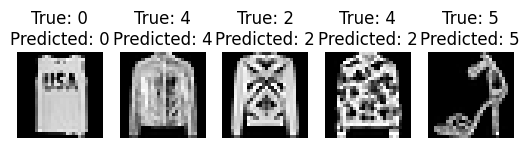

In [27]:
import matplotlib.pyplot as plt
import numpy as np

#1 Set the model to evaluation mode
model.eval()

#2 Choose a few images from the testing set
num_images_to_predict = 5
dataiter = iter(test_loader)

#3 Make predictions
with torch.no_grad():
    images, labels = next(dataiter)
    images_to_predict = images[:num_images_to_predict]
    labels_to_predict = labels[:num_images_to_predict]

    model_predictions = model(images_to_predict)
    _, predicted_labels = torch.max(model_predictions, 1)

#4 Display the images along with their true and predicted labels
for i in range(num_images_to_predict):
    image = images_to_predict[i].numpy().squeeze()
    true_label = labels_to_predict[i].item()
    predicted_label = predicted_labels[i].item()

    plt.subplot(1, num_images_to_predict, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'True: {true_label}\nPredicted: {predicted_label}')
    plt.axis('off')

plt.show()


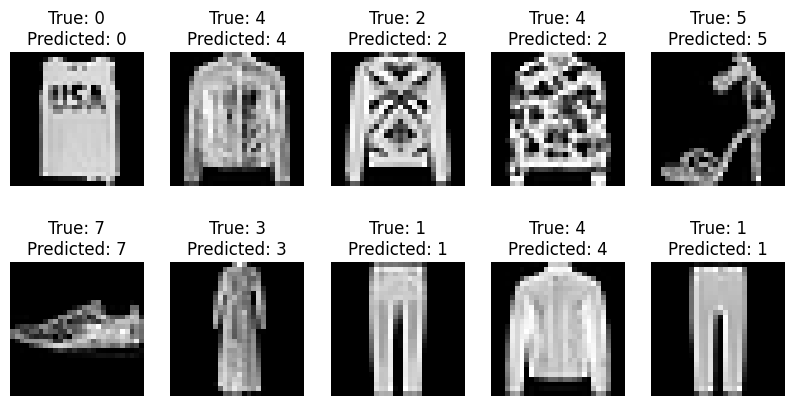

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Set the model to evaluation mode
model.eval()

# Choose 10 images from the testing set
num_images_to_predict = 10
dataiter = iter(test_loader)

# Make predictions
with torch.no_grad():
    images, labels = next(dataiter)
    images_to_predict = images[:num_images_to_predict]
    labels_to_predict = labels[:num_images_to_predict]

    model_predictions = model(images_to_predict)
    _, predicted_labels = torch.max(model_predictions, 1)

# Display the images along with their true and predicted labels
plt.figure(figsize=(10, 5))
for i in range(num_images_to_predict):
    image = images_to_predict[i].numpy().squeeze()
    true_label = labels_to_predict[i].item()
    predicted_label = predicted_labels[i].item()

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'True: {true_label}\nPredicted: {predicted_label}')
    plt.axis('off')

plt.show()


2.8

Discussion on Model Performance:

Test Accuracy: Evaluate the overall test accuracy to understand how well the model generalizes to unseen data. A high test accuracy indicates good performance.

Visual Inspection: Examine the visualized images along with their true and predicted labels. This provides insights into specific examples where the model performs well or struggles.

Loss Metrics: Consider the average test loss. A lower test loss generally indicates better performance

Confusion Matrix: Create a confusion matrix to analyze the distribution of true positive, true negative, false positive, and false negative predictions across different classes.


Challenges Faced During Training:

Overfitting: Watch for signs of overfitting, where the model performs well on the training set but poorly on the test set. If overfitting occurs, consider adding regularization techniques like dropout or reducing model complexity.

Hyperparameter Tuning: Finding the right set of hyperparameters (learning rate, batch size, etc.) can be challenging

Hyperparameter Tuning: Systematically explore different hyperparameter combinations to find the optimal set for your specific task.

Data Quality: Ensure the quality and representativeness of the training data. If possible, clean the data and address any issues that may affect model performance.

Ensemble Methods: Consider using ensemble methods to combine predictions from multiple models. This can often lead to better performance than a single model.

Learning Rate Scheduling: Implement learning rate scheduling to dynamically adjust the learning rate during training, which can help the model converge faster and more effectively.

Early Stopping: Implement early stopping to halt training when the model's performance on the validation set stops improving. This prevents overfitting.

Class Imbalance Handling: If there is a class imbalance, consider techniques such as class weighting or oversampling the minority class to improve the model's ability to learn from all classes.

3

3.1

In [29]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load Fashion MNIST datasets
train_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
test_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)

# Set batch size for data loaders
batch_size = 64

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print the size of the datasets
print("Training Data Size:", len(train_loader.dataset))
print("Test Data Size:", len(test_loader.dataset))


Training Data Size: 60000
Test Data Size: 10000


3.2

Data Transformations (Step #2):

The transforms.Compose function is used to define a sequence of transformations.
transforms.ToTensor() converts the images to PyTorch tensors.
transforms.Lambda(lambda x: x.view(-1)) flattens the 2D images to 1D arrays.
transforms.Normalize((0.0,), (1.5,)) normalizes the pixel values to the specified range.

Download the Fashion MNIST dataset (Step #3):

The datasets.FashionMNIST class is used to download and load the Fashion MNIST dataset, applying the defined transformations.

Normalize Pixel Values (Step #4):

Pixel values are normalized to a range between 0 and 1.

Split the Dataset (Steps #5 and #6):

The train_test_split function from scikit-learn is used to split the dataset into training, testing, and validation sets.
The stratify parameter ensures that the class distribution is preserved in the splits.

Create PyTorch Tensors (Step #7):

PyTorch tensors are created for the training, testing, and validation data along with their respective labels.

Create Data Loaders (Step #8):

PyTorch DataLoader objects are created for the training, testing, and validation datasets, specifying batch size and shuffle settings.

Print Dataset Sizes:

The sizes of the training, validation, and testing datasets are printed.

Flatten the 2D images into 1D arrays. why?

Vectorized Representation: Many machine learning algorithms, especially those in traditional machine learning libraries, operate on vectorized input data. Flattening the 2D images into 1D arrays allows each pixel to be treated as a separate feature, resulting in a vectorized representation of the image.

Compatibility with Fully Connected Layers: In neural networks, fully connected layers (or dense layers) expect one-dimensional input. By flattening the 2D images, you can connect the output of the flattening operation directly to a fully connected layer in a neural network.

Simplicity and Consistency: Flattening simplifies the input data structure and makes it consistent across different images. Regardless of the original image dimensions, flattening ensures that each image is represented as a fixed-size vector.

Original 2D Image (28x28):
[[pixel_00, pixel_01, ..., pixel_27],
 [pixel_10, pixel_11, ..., pixel_37],
 ...,
 [pixel_27, pixel_26, ..., pixel_27]]

Flattened 1D Array (784 elements):
[pixel_00, pixel_01, ..., pixel_27, pixel_10, pixel_11, ..., pixel_37, ..., pixel_27]

flattening simplifies the representation of images, making it compatible with a wide range of machine learning models, and it ensures consistency in the input format across different images.


In [30]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

#2 Define data transformations (flatten, normalize, and split)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),  # Flatten the 2D images to 1D arrays
    transforms.Normalize((0.0,), (1.5,))
])

#3 Download the Fashion MNIST dataset
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

#4 Normalize pixel values to a range between 0 and 1
normalized_data = (dataset.data.float() / 255.0).unsqueeze(1)  # Normalize and add channel dimension

#5 Split the dataset into training, testing, and validation sets
train_data, test_data, train_labels, test_labels = train_test_split(
    normalized_data, dataset.targets, test_size=0.2, random_state=42, stratify=dataset.targets)

#6 Further split the test set into test and validation sets
test_data, val_data, test_labels, val_labels = train_test_split(
    test_data, test_labels, test_size=0.5, random_state=42, stratify=test_labels)

#7 Create PyTorch tensors for the data and labels
train_dataset = torch.utils.data.TensorDataset(train_data, train_labels)
test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
val_dataset = torch.utils.data.TensorDataset(val_data, val_labels)

#8 Create data loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)

print("Training Data Size:", len(train_loader.dataset))
print("Validation Data Size:", len(val_loader.dataset))
print("Test Data Size:", len(test_loader.dataset))

Training Data Size: 48000
Validation Data Size: 6000
Test Data Size: 6000


3.3

#1.Defining MLP Class:
    This line defines a class named MLP that inherits from nn.Module. This class will represent our Multi-Layer Perceptron model.

#2.MLP Class Constructor:
    This line defines the constructor method (__init__) for the MLP class. It takes input size, hidden layer sizes, output size, and an activation function as parameters. The default activation function is set to 'relu'.

#3.Activation Function Validation:
This block checks if the provided activation function is valid. If it's not one of 'relu', 'sigmoid', or 'tanh', it raises a ValueError

#4.Initializing Layers List:
This line creates an empty list named layers to hold the layers of the MLP.

#5.Adding Input Layer:
Two layers are added to the layers list. The first is a fully connected (linear) layer with input size input_size and output size hidden_sizes[0]. The second layer is the activation function specified by activation_function.

#6.Adding Hidden Layers:
A loop is used to add hidden layers to the layers list. Each iteration adds a fully connected layer followed by the specified activation function.

#7.Adding Output Layer:
The output layer is added to the layers list. It is a fully connected layer with input size hidden_sizes[-1] and output size output_size.

#8.Creating Sequential Model:
This line creates a PyTorch nn.Sequential model using the list of layers (layers). The *layers syntax unpacks the list, passing each layer as a separate argument to nn.Sequential.

#9.Forward Method:
This line defines the forward method of the model. It takes an input x and passes it through the sequential model (self.model), returning the output.

#10.Activation Function Helper Function:
This section defines a helper function named get_activation that returns the appropriate activation function module based on the specified activation function string.

#11.etting Model Parameters:
These lines specify the parameters for creating an instance of the MLP model. It includes the input size, hidden layer sizes, output size, and the activation function

#12.Creating Model Instance:
This line creates an instance of the MLP model using the specified parameters.

Printing Model Architecture:
This line prints the architecture of the created model, which includes information about each layer and activation function.

Explanation of the output:

The model is encapsulated within the MLP class, and it contains a Sequential module named model.
The Sequential module consists of several layers, each identified by an index.
The first layer (index 0) is a linear (fully connected) layer with input features (in_features) of 784 and output features (out_features) of 256. It includes a bias term (bias=True).
The second layer (index 1) is a ReLU activation function applied to the output of the first layer.
The third layer (index 2) is another linear layer with input features of 256 and output features of 128.
The fourth layer (index 3) is another ReLU activation function applied to the output of the second linear layer.
The fifth layer (index 4) is the output layer, a linear layer with input features of 128 and output features of 10, corresponding to the number of classes in the classification task.

In [31]:
import torch
import torch.nn as nn
#1
class MLP(nn.Module):
    #2
    def __init__(self, input_size, hidden_sizes, output_size, activation_function='relu'):
        super(MLP, self).__init__()

        #3 Check if the chosen activation function is valid
        if activation_function not in ['relu', 'sigmoid', 'tanh']:
            raise ValueError("Invalid activation function. Choose from 'relu', 'sigmoid', or 'tanh'.")

        #4 Create a list to hold the layers of the MLP
        layers = []

        #5 Add the input layer
        layers.append(nn.Linear(input_size, hidden_sizes[0]))
        layers.append(get_activation(activation_function))

        #6 Add hidden layers
        for i in range(1, len(hidden_sizes)):
            layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
            layers.append(get_activation(activation_function))

        #7 Add the output layer
        layers.append(nn.Linear(hidden_sizes[-1], output_size))

        #8 Combine all layers into a sequential model
        self.model = nn.Sequential(*layers)
    #9
    def forward(self, x):
        return self.model(x)
#10
def get_activation(activation_function):
    if activation_function == 'relu':
        return nn.ReLU()
    elif activation_function == 'sigmoid':
        return nn.Sigmoid()
    elif activation_function == 'tanh':
        return nn.Tanh()
#11
# Specify input size, hidden layer sizes, output size, and activation function
input_size = 28 * 28  # Flattened image dimensions
hidden_sizes = [256, 128]  # Experiment with different hidden layer sizes
output_size = 10  # Number of classes (Fashion MNIST has 10 classes)
activation_function = 'relu'  # Experiment with 'relu', 'sigmoid', or 'tanh'

#12
# Create an instance of the MLP model
mlp_model = MLP(input_size, hidden_sizes, output_size, activation_function)

# Print the model architecture
print(mlp_model)


MLP(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


3.4

Loss Function (criterion):

    For a classification task, nn.CrossEntropyLoss() is commonly used. It combines a softmax activation and a negative log-likelihood loss. It is suitable when the model is outputting raw scores/logits for each class.

Optimizer (optimizer):

    optim.Adam(model.parameters(), lr=0.001) selects the Adam optimizer with a learning rate of 0.001. Adam is a popular optimization algorithm that adapts the learning rates for each parameter individually.

Metric for Evaluation (accuracy):

    Accuracy is a common metric for classification tasks. The accuracy function calculates the ratio of correctly predicted samples to the total number of samples. 


In [34]:
import torch.optim as optim

# Choose the loss function
criterion = nn.CrossEntropyLoss()

# Choose the optimizer
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# Specify a metric for model evaluation (optional, accuracy is commonly used)
def accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total

# You can use the above accuracy function during training or evaluation


3.5

#1.Checks if a GPU is available. If so, sets the device to GPU; otherwise, uses the CPU.

#2.Moves the MLP model to the selected device (GPU or CPU).

#3.Defines a function named evaluate that takes four parameters:
    model: The PyTorch model to be evaluated.
    dataloader: The DataLoader containing the evaluation dataset.
    criterion: The loss function used for evaluation.
    metric: A custom metric function used to evaluate the model's performance.
#4
Puts the model in evaluation mode. This is important because it disables certain operations like dropout during evaluation.

#5
Initializes variables to accumulate the total loss and total metric during the evaluation.

#6
Inside this block, gradients are not calculated, which reduces memory consumption and speeds up computation during evaluation.

#7
Iterates over the batches in the evaluation dataloader.

#8
Performs a forward pass through the model to obtain predictions (outputs). The input data is flattened using view before being fed into the model.

#9
Computes the loss between the model's predictions (outputs) and the actual labels.

#10
Accumulates the loss for the entire evaluation dataset.

#11
Accumulates the custom evaluation metric for the entire evaluation dataset.

#12
Calculates the average loss and average metric over all batches in the evaluation dataset.

#13
Returns the average loss and average metric as a tuple. This information can be used to assess the model's performance on the evaluation dataset.



#14
Iterates over the specified number of epochs.

#15
Sets the MLP model to training mode. This is important because it enables certain operations like dropout during training.

#16
Initializes variables to accumulate the total loss and total metric during the training epoch.

#17
Iterates over batches in the training dataloader.

#18
Moves the input data and labels to the specified device (GPU or CPU). The input data is flattened using view before being fed into the model.

#19
Zeros the gradients of the model parameters. This is necessary before computing gradients in the backward pass.

#20
Performs a forward pass through the model to obtain predictions (outputs). Computes the loss between the model's predictions and the actual labels.

#21
Performs the backward pass to compute gradients and then updates the model parameters using the chosen optimizer.

#22
Accumulates the loss and custom accuracy metric for the current batch.

#23
Calculates the average loss and average metric over all batches in the training dataset for the current epoch.

#24
Prints training statistics for the current epoch, including average loss and average accuracy.

#25
After training, evaluates the trained model on the test set using the evaluate function.


output:

    This information gives you insights into how well the model is learning from the training data over epochs. You would ideally observe a decrease in loss and an increase in accuracy as the model learns.

After Training Output:

    After completing all epochs of training, the code proceeds to evaluate the model on the test set.
    It prints the average loss and accuracy on the test set.

This information provides an indication of how well the model generalizes to unseen data (test set). You would ideally want good accuracy and low loss on the test set, indicating that the model has learned to make accurate predictions on new, unseen examples.

In [36]:
import torch

#1 Set the device to GPU if available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#2 Move the model to the selected device
mlp_model.to(device)

# Set up the loss function, optimizer, and evaluation metric
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)
accuracy_metric = accuracy  # You can define your own metric function if needed

# Training hyperparameters
num_epochs = 10
batch_size = 64

#3 Example of using accuracy as an evaluation metric
def evaluate(model, dataloader, criterion, metric):
    #4
    model.eval()
    #5
    total_loss = 0.0
    total_metric = 0.0
    #6
    with torch.no_grad():
        #7
        for inputs, labels in dataloader:
            #8
            outputs = model(inputs.view(inputs.size(0), -1))
            #9
            loss = criterion(outputs, labels)
            #10
            total_loss += loss.item()
            #11
            total_metric += metric(outputs, labels)
    #12
    average_loss = total_loss / len(dataloader)
    average_metric = total_metric / len(dataloader)
    #13
    return average_loss, average_metric


# Training loop
#14
for epoch in range(num_epochs):
    #15
    mlp_model.train()
    #16
    running_loss = 0.0
    running_metric = 0.0
    #17
    for inputs, labels in train_loader:
        #18 Move data to the device
        inputs, labels = inputs.view(inputs.size(0), -1).to(device), labels.to(device)

        #19 Zero the parameter gradients
        optimizer.zero_grad()

        #20 Forward pass
        outputs = mlp_model(inputs)
        loss = criterion(outputs, labels)

        #21 Backward pass and optimization
        loss.backward()
        optimizer.step()
        #22
        running_loss += loss.item()
        running_metric += accuracy_metric(outputs, labels)

    #23 Calculate average loss and metric for the epoch
    average_loss = running_loss / len(train_loader)
    average_metric = running_metric / len(train_loader)

    #24 Print training statistics
    print(f"Epoch {epoch + 1}/{num_epochs} => "
          f"Loss: {average_loss:.4f}, "
          f"Accuracy: {average_metric:.4f}")

#25 After training, you may want to evaluate the model on the test set
test_loss, test_accuracy = evaluate(mlp_model, test_loader, criterion, accuracy_metric)
print(f"\nTest Set => Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}")


Epoch 1/10 => Loss: 0.5544, Accuracy: 0.8030
Epoch 2/10 => Loss: 0.3889, Accuracy: 0.8563
Epoch 3/10 => Loss: 0.3453, Accuracy: 0.8736
Epoch 4/10 => Loss: 0.3231, Accuracy: 0.8806
Epoch 5/10 => Loss: 0.2987, Accuracy: 0.8884
Epoch 6/10 => Loss: 0.2829, Accuracy: 0.8940
Epoch 7/10 => Loss: 0.2709, Accuracy: 0.8982
Epoch 8/10 => Loss: 0.2592, Accuracy: 0.9023
Epoch 9/10 => Loss: 0.2463, Accuracy: 0.9071
Epoch 10/10 => Loss: 0.2341, Accuracy: 0.9119

Test Set => Loss: 0.3010, Accuracy: 0.8972


3.6

#1
Invokes the evaluate function to calculate the average loss and accuracy on the test set using the trained MLP model. The returned values are assigned to test_loss and test_accuracy.

#2
Imports necessary functions (precision_score, recall_score, f1_score) from scikit-learn to calculate additional metrics.

#3
Initializes empty lists (all_predictions and all_labels) to store predictions and actual labels.
Iterates over batches in the test loader and makes predictions using the trained model.
Extends the lists with the predictions and actual labels.

#4
Calculates precision, recall, and F1 score using scikit-learn metrics. The average='weighted' parameter computes metrics for each class and then averages them, weighted by the number of true instances in each class.


This code section provides a comprehensive evaluation of the trained MLP model on the test set by calculating multiple metrics beyond accuracy, offering a more detailed understanding of the model's performance.


output
Test Set Loss and Accuracy:

Loss: 0.3010: Average loss calculated on the test set. It represents how well the model's predictions match the true labels, with lower values indicating better performance.

Accuracy: 0.8972: The accuracy of the model on the test set. It represents the proportion of correctly classified instances.

Precision, Recall, and F1 Score:

Precision: 0.8987: Precision is a metric that measures the accuracy of positive predictions. It is the ratio of correctly predicted positive observations to the total predicted positives.

Recall: 0.8972: Recall, also known as sensitivity or true positive rate, is the ratio of correctly predicted positive observations to the all observations in the actual class.

F1 Score: 0.8970: The F1 score is the harmonic mean of precision and recall. It provides a balance between precision and recall, and it's particularly useful when there is an uneven class distribution.

These metrics collectively offer insights into different aspects of the model's performance. A good model would generally have low test set loss, high accuracy, precision, recall, and F1 score.




In [37]:
#1 After training, you may want to evaluate the model on the test set
test_loss, test_accuracy = evaluate(mlp_model, test_loader, criterion, accuracy_metric)

#2 you can calculate precision, recall, and F1 score using scikit-learn
from sklearn.metrics import precision_score, recall_score, f1_score

#3 Make predictions on the test set
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.view(inputs.size(0), -1).to(device), labels.to(device)
        outputs = mlp_model(inputs)
        predictions = torch.argmax(outputs, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate additional metrics
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')

# Display metrics
print(f"\nTest Set => Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")



Test Set => Loss: 0.3010, Accuracy: 0.8972
Precision: 0.8987, Recall: 0.8972, F1 Score: 0.8970


3.7

#1
Defines the number of images you want to display from the testing set (num_images_to_display).

#2
Iterates over the test_loader to obtain a batch of images and labels.
Transfers the images and labels to the specified device (GPU or CPU).
Breaks out of the loop after the first batch is obtained.

#3
Uses the trained model to make predictions on the chosen batch of images.
torch.no_grad() is used to ensure that gradients are not calculated during predictions, reducing memory consumption.
torch.argmax(outputs, dim=1) finds the predicted classes.

#4
Creates a visualization using matplotlib to display the chosen images along with their true labels and predicted labels.
Loops through each image in the chosen batch, plots it, and adds a title indicating the true and predicted classes.
plt.show() displays the visualization. Adjust the figure size, number of images, or other parameters as needed.


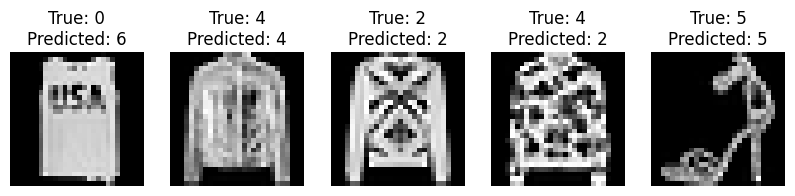

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Set the model to evaluation mode
mlp_model.eval()

#1 Choose a few images from the testing set
num_images_to_display = 5

#2 Iterate over the test loader to get a batch of images and labels
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    break  # Stop after the first batch

#3 Make predictions using the trained model
with torch.no_grad():
    outputs = mlp_model(images.view(images.size(0), -1))
    predictions = torch.argmax(outputs, dim=1)

#4 Display the images and their predicted classes
plt.figure(figsize=(10, 3))

for i in range(num_images_to_display):
    plt.subplot(1, num_images_to_display, i + 1)
    plt.imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
    plt.title(f"True: {labels[i].item()}\nPredicted: {predictions[i].item()}")
    plt.axis('off')

plt.show()


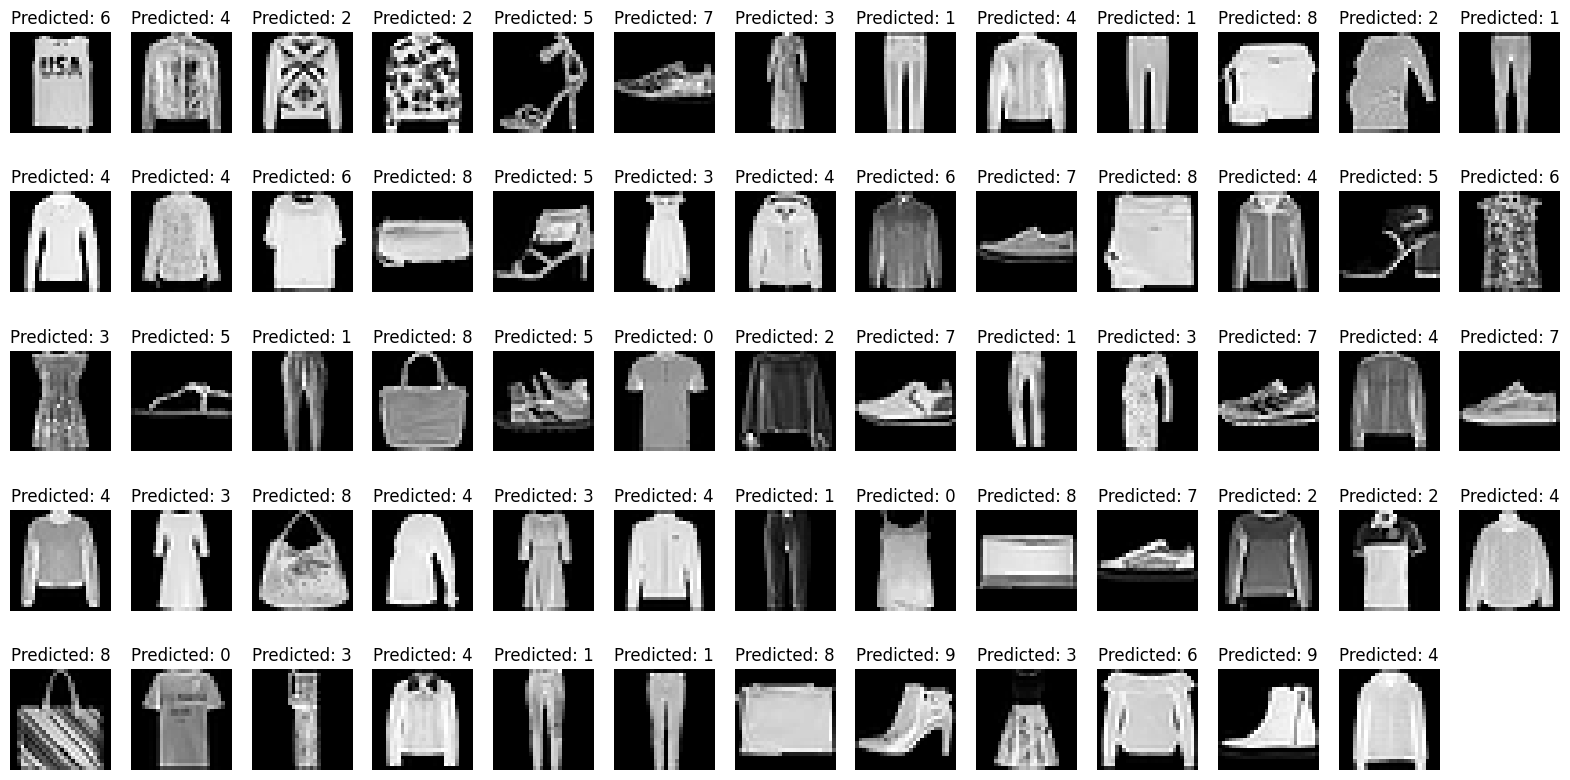

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Set the model to evaluation mode
mlp_model.eval()

# Load a batch of images and labels from the testing set
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    break  # Stop after the first batch

# Make predictions using the trained model
with torch.no_grad():
    outputs = mlp_model(images.view(images.size(0), -1))
    predictions = torch.argmax(outputs, dim=1)

# Display the images and their predicted classes in 5 rows
num_rows = 5  # Set the number of rows
num_cols = (len(images) + num_rows - 1) // num_rows
plt.figure(figsize=(20, 10))

for i in range(len(images)):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
    plt.title(f"Predicted: {predictions[i].item()}")
    plt.axis('off')

plt.show()

3.8

Comparison of MLP and CNN Performance:

MLP (Multi-Layer Perceptron):

    MLPs are generally not well-suited for image classification tasks, especially on datasets like Fashion MNIST, which contains structured patterns. They lack the ability to capture spatial relationships in images and may struggle with complex patterns.

CNN (Convolutional Neural Network):

    CNNs are designed to handle spatial relationships in images efficiently. They use convolutional layers to learn hierarchical features and are more effective in capturing patterns in images.

    On image-related tasks, CNNs often outperform MLPs due to their ability to recognize spatial hierarchies and patterns.


Challenges Faced:

Model Complexity:
MLPs may struggle with the complexity of image datasets like Fashion MNIST. They lack the inherent ability to recognize spatial patterns, leading to suboptimal performance.

Spatial Hierarchies:
Fashion MNIST contains images with spatial hierarchies (e.g., edges, textures, shapes) that are crucial for accurate classification. MLPs do not explicitly consider these spatial relationships.

Overfitting:
Both MLPs and CNNs can face overfitting challenges, especially if the models are too complex for the given dataset. Regularization techniques may be needed to address overfitting.

Limited Capacity of MLP:
MLPs might not have enough capacity to effectively learn complex features, leading to underperformance compared to more sophisticated architectures like CNNs.

Use CNN Architecture:
If the task involves image classification, it's often beneficial to use CNN architectures. CNNs are specifically designed for image-related tasks and excel at capturing spatial hierarchies.

Data Augmentation:
Augmenting the dataset with techniques like rotation, flipping, and scaling can help the model generalize better and reduce overfitting.

Transfer Learning:
Leveraging pre-trained models, especially on larger datasets, through transfer learning can provide a good starting point. Fine-tuning a pre-trained CNN on Fashion MNIST might yield better results.

Hyperparameter Tuning:
Experimenting with different hyperparameter configurations, including learning rates, batch sizes, and model architectures, can lead to improved performance.


In conclusion, for image-related tasks, especially on datasets like Fashion MNIST, CNNs are generally more suitable and effective compared to MLPs. The challenges faced can often be mitigated by leveraging appropriate architectures, data augmentation, regularization techniques, and other advanced strategies.

4

4.1

import torch: Import the PyTorch library.

from torchvision import datasets, transforms: Import the necessary modules from torchvision, including datasets and transforms.

import matplotlib.pyplot as plt: Import the matplotlib.pyplot module for plotting.

import seaborn as sns: Import the seaborn library for statistical data visualization.

transform = transforms.Compose([...]): Define a sequence of transformations to be applied to the data. In this case, it includes converting the image to a PyTorch tensor and normalizing pixel values.

full_dataset = datasets.FashionMNIST(..., transform=transform): Load the Fashion MNIST dataset using torchvision. Apply the specified transformations to the dataset during loading.

labels = [label for _, label in full_dataset]: Extract the class labels from the loaded dataset.

plt.figure(figsize=(10, 6)): Create a figure for plotting with a specified size.

sns.countplot(x=labels): Use seaborn to create a count plot of the class labels.

plt.title('Distribution of Classes in Fashion MNIST Dataset'): Set the title for the plot.

plt.xlabel('Class Label'): Set the label for the x-axis.

plt.ylabel('Count'): Set the label for the y-axis.

plt.show(): Display the plot.

class_counts = torch.tensor(labels).bincount(): Count the occurrences of each class label using PyTorch's bincount.

class_labels = list(range(len(class_counts))): Create a list of class labels.

plt.figure(figsize=(10, 6)): Create a new figure for plotting.

plt.bar(class_labels, class_counts): Create a bar plot of the class distribution.

plt.title('Class Distribution in Fashion MNIST Dataset'): Set the title for the plot.

plt.xlabel('Class Label'): Set the label for the x-axis.

plt.ylabel('Count'): Set the label for the y-axis.

plt.xticks(class_labels): Set the x-axis ticks to correspond to the class labels.

plt.show(): Display the plot.

Loop through the class counts and print the count for each class.

#1
Check for class imbalance by comparing if any class count is less than 10% of the count of the most frequent class.

Print whether the dataset is balanced or has class imbalance.

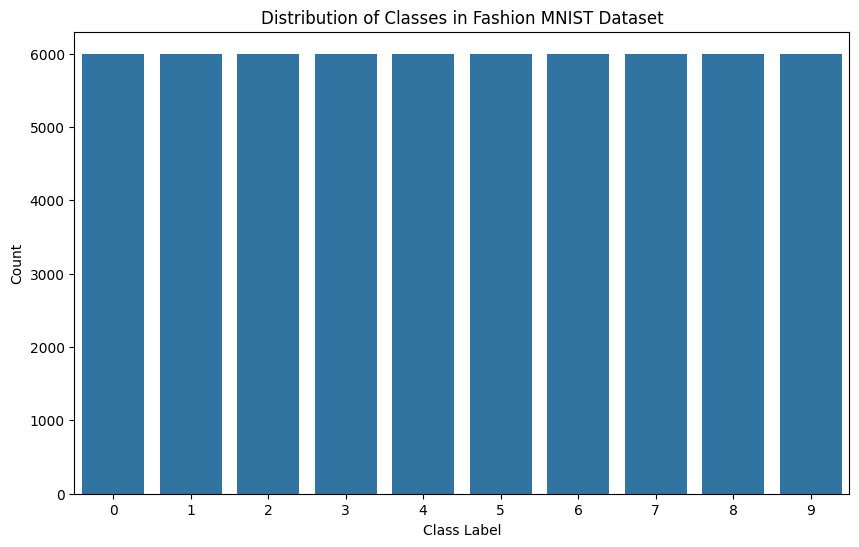

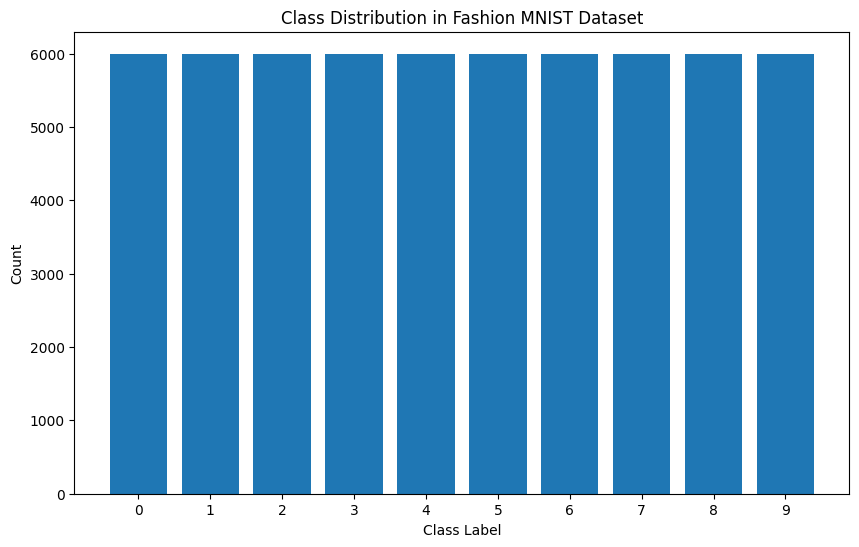

Class 0: 6000 samples
Class 1: 6000 samples
Class 2: 6000 samples
Class 3: 6000 samples
Class 4: 6000 samples
Class 5: 6000 samples
Class 6: 6000 samples
Class 7: 6000 samples
Class 8: 6000 samples
Class 9: 6000 samples
The dataset is balanced.


In [60]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Fashion MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.0,), (1.5,))
])

full_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)

# Extract labels from the dataset
labels = [label for _, label in full_dataset]

# Visualize the distribution of classes
plt.figure(figsize=(10, 6))
sns.countplot(x=labels)
plt.title('Distribution of Classes in Fashion MNIST Dataset')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

# Examine class balance
class_counts = torch.tensor(labels).bincount()
class_labels = list(range(len(class_counts)))

plt.figure(figsize=(10, 6))
plt.bar(class_labels, class_counts)
plt.title('Class Distribution in Fashion MNIST Dataset')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(class_labels)
plt.show()

# Print class counts
for i, count in enumerate(class_counts):
    print(f"Class {i}: {count} samples")

#1 Check for class imbalance
is_imbalanced = any(count < 0.1 * max(class_counts) for count in class_counts)
if is_imbalanced:
    print("The dataset has class imbalance.")
else:
    print("The dataset is balanced.")


4.2

import torch: Import the PyTorch library.

from torchvision import datasets, transforms: Import modules from torchvision, including datasets and transforms.

import numpy as np: Import NumPy for numerical operations.

import matplotlib.pyplot as plt: Import the matplotlib.pyplot module for plotting.

transform = transforms.Compose([transforms.ToTensor()]): Create a transformation pipeline using transforms.Compose. In this case, it only includes transforms.ToTensor(), which converts images to PyTorch tensors.

full_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform): Load the Fashion MNIST dataset with the specified transform.

all_images = torch.cat([img.unsqueeze(0) for img, label in full_dataset], dim=0): Concatenate all images from the dataset into a single tensor. img.unsqueeze(0) is used to add a batch dimension.

mean = all_images.mean(dim=(0, 2, 3)).numpy(): Calculate the mean along dimensions (0, 2, 3) to obtain mean values for each channel.

std = all_images.std(dim=(0, 2, 3)).numpy(): Calculate the standard deviation along dimensions (0, 2, 3) to obtain standard deviation values for each channel.

print("Mean:", mean.item()): Print the mean value.

print("Standard Deviation:", std.item()): Print the standard deviation value.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)): Create a figure with two subplots.

ax1.bar(range(len(mean)), mean): Plot the mean values in the first subplot.

ax1.set_title('Mean Pixel Value'): Set the title for the first subplot.

ax2.bar(range(len(std)), std): Plot the standard deviation values in the second subplot.

ax2.set_title('Standard Deviation of Pixel Values'): Set the title for the second subplot.

plt.show(): Display the plots.

Output Display:

    The mean and standard deviation values are printed to the console.

Visualizations:

    First Subplot (Mean Pixel Value):

    Displays a bar plot where each bar represents the mean value for a channel (assuming RGB channels, as Fashion MNIST is grayscale).
    The x-axis corresponds to the channel indices (0, 1, 2, ...).
    The y-axis represents the mean pixel value for each channel.
    The title of the subplot is set to 'Mean Pixel Value.'


    Second Subplot (Standard Deviation of Pixel Values):

    Similar to the first subplot, but it displays the standard deviation values for each channel.
    The title of the subplot is set to 'Standard Deviation of Pixel Values.'

Interpretation:

    The bar plots provide insights into the distribution of pixel values across different channels. It helps you understand the overall brightness and contrast characteristics of the images in the Fashion MNIST dataset.

    If the mean plot shows that a particular channel has a significantly higher mean value compared to others, it might suggest a bias or a dominant color intensity.

    The standard deviation plot indicates the variability of pixel values. Higher standard deviation values suggest more diverse pixel values, while lower values indicate more uniform pixel distributions.

    The visualizations are useful for preprocessing decisions, such as normalization, in image processing tasks.


Mean: 0.28604060411453247
Standard Deviation: 0.3530242443084717


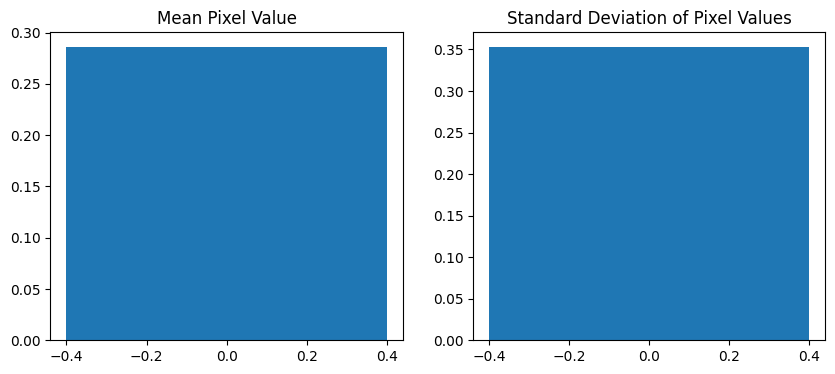

In [8]:
import torch
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Define a transform with normalization for visualization
visualization_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the entire Fashion MNIST dataset without normalization
full_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)

# Concatenate all images into a single tensor
all_images = torch.cat([img.unsqueeze(0) for img, label in full_dataset], dim=0)

# Calculate mean and standard deviation
mean = all_images.mean(dim=(0, 2, 3)).numpy()
std = all_images.std(dim=(0, 2, 3)).numpy()

print("Mean:", mean.item())
print("Standard Deviation:", std.item())
# Visualize the mean and standard deviation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot the mean
ax1.bar(range(len(mean)), mean)
ax1.set_title('Mean Pixel Value')

# Plot the standard deviation
ax2.bar(range(len(std)), std)
ax2.set_title('Standard Deviation of Pixel Values')

plt.show()


4.3

Import Libraries:
import torch: Import the PyTorch library.
from torchvision import datasets, transforms: Import modules from torchvision, including datasets and transforms.
import matplotlib.pyplot as plt: Import the matplotlib.pyplot module for plotting.
import random: Import the random module for selecting random samples.

Define Transformation for Visualization:
visualization_transform is defined using transforms.Compose.
It includes transforms.ToTensor() to convert images to PyTorch tensors.
It includes transforms.Normalize((0.5,), (0.5,)) to normalize pixel values to the range [-1, 1].

Load Sample Fashion MNIST Dataset:
sample_dataset is created using the Fashion MNIST dataset.
The specified visualization_transform is applied during loading.

Display Image Dimensions:
A loop iterates over 5 random samples from the sample_dataset.
The shape (dimensions) and label of each image are printed.

Visualize Sample Images:
Another loop visualizes 5 random samples from the sample_dataset.
Subplots are created for each sample, displaying the images with labels.
plt.show() displays the visualization.


A figure with 5 subplots is displayed, each containing a randomly selected Fashion MNIST image. The images are shown in grayscale, and each subplot is labeled with its corresponding class label. 

output:
torch.Size([1, 28, 28]) indicates that the images are grayscale with a size of 28x28 pixels.

Label indicates the class label assigned to each image.


Input Parameter (dataset):

    The function takes a PyTorch dataset (dataset) as input, assuming it contains images.

Exploration of Image Dimensions:

    A loop iterates over 5 random samples from the provided dataset.
    For each sample, it prints the shape (dimensions) of the image tensor and its corresponding label.

Visualization of Sample Images:

    Another loop selects 5 random samples from the dataset.
    It visualizes the images in a subplot grid using matplotlib.
    The images are shown in grayscale with their corresponding class labels.
    The visualization provides insights into the appearance and variability of images in the dataset.


Sample 1: Image shape - torch.Size([1, 28, 28]), Label - 2
Sample 2: Image shape - torch.Size([1, 28, 28]), Label - 6
Sample 3: Image shape - torch.Size([1, 28, 28]), Label - 9
Sample 4: Image shape - torch.Size([1, 28, 28]), Label - 3
Sample 5: Image shape - torch.Size([1, 28, 28]), Label - 2


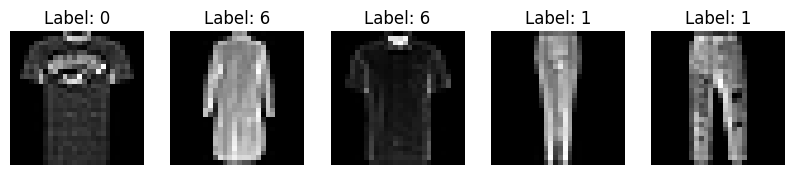

In [9]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random

# Define a transform with normalization for visualization
visualization_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load a sample of the Fashion MNIST dataset without normalization
sample_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)

# Display the dimensions of a few sample images
for i in range(5):
    img, label = random.choice(sample_dataset)
    print(f"Sample {i + 1}: Image shape - {img.shape}, Label - {label}")

# Visualize a few sample images
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i in range(5):
    img, label = random.choice(sample_dataset)
    axes[i].imshow(img.squeeze().numpy(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.show()


Unique Image Dimensions in the Dataset: {torch.Size([1, 28, 28])}


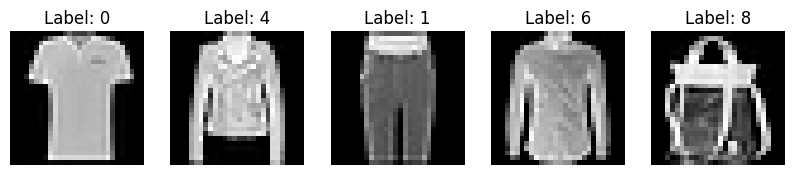

In [10]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random

# Define a transform with normalization for visualization
visualization_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the Fashion MNIST dataset without normalization
full_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=visualization_transform)

# Explore image dimensions
image_dimensions = set(img.shape for img, label in full_dataset)
print("Unique Image Dimensions in the Dataset:", image_dimensions)

# Visualize a few sample images
num_samples = 5
sample_indices = random.sample(range(len(full_dataset)), num_samples)

plt.figure(figsize=(10, 3))
for i, idx in enumerate(sample_indices, 1):
    image, label = full_dataset[idx]
    plt.subplot(1, num_samples, i)
    plt.imshow(image.squeeze().numpy(), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.show()


4.4

Concatenate Images into a Single Tensor:
    Concatenate all images into a single tensor (all_images) using torch.cat.
    img.unsqueeze(0) is used to add a singleton dimension (unsqueeze) to each image.

Reshape the Tensor:
    Reshape the tensor (reshaped_images) to have samples along the first dimension using view.

Calculate Correlation Matrix:
    Use NumPy (np.corrcoef) to calculate the correlation matrix (correlation_matrix) from the reshaped tensor.

Create Correlation Heatmap:
    Create a heatmap using seaborn (sns.heatmap) to visualize the correlation matrix.
    The colormap 'coolwarm' is used, and both x-axis and y-axis labels are turned off for clarity.

Display the Correlation Heatmap:
    Display the correlation heatmap using plt.show().

This code provides a visual representation of the correlations between pixel values in the Fashion MNIST images. The heatmap helps identify patterns and relationships between different pixels in the dataset.


Correlation Heatmap:

The main output is a heatmap created using seaborn (sns.heatmap).

Each cell in the heatmap represents the correlation between two pixels in the reshaped Fashion MNIST images.

The colors in the heatmap indicate the strength and direction of the correlation:
    Dark blue represents a strong negative correlation.
    Dark red represents a strong positive correlation.
    Lighter colors indicate weaker correlations or no correlation.

Heatmap Appearance:
    The heatmap is displayed in a new window with a title: 'Correlation Heatmap of Pixel Values'.
    The x-axis and y-axis represent different pixels in the reshaped images, and the cells show the correlation values between them.

Visualization Settings:
    The colormap 'coolwarm' is used, which transitions from cool colors (blue) to warm colors (red).
    Both x-axis and y-axis labels are turned off (xticklabels=False, yticklabels=False) for clarity, as the focus is on the correlation patterns rather than specific pixel indices.

Figure Size:
    The size of the heatmap figure is set to (10, 8) for better visibility.

By analyzing the heatmap, you can gain insights into which pixels have stronger correlations, helping you understand patterns and relationships within the Fashion MNIST dataset.


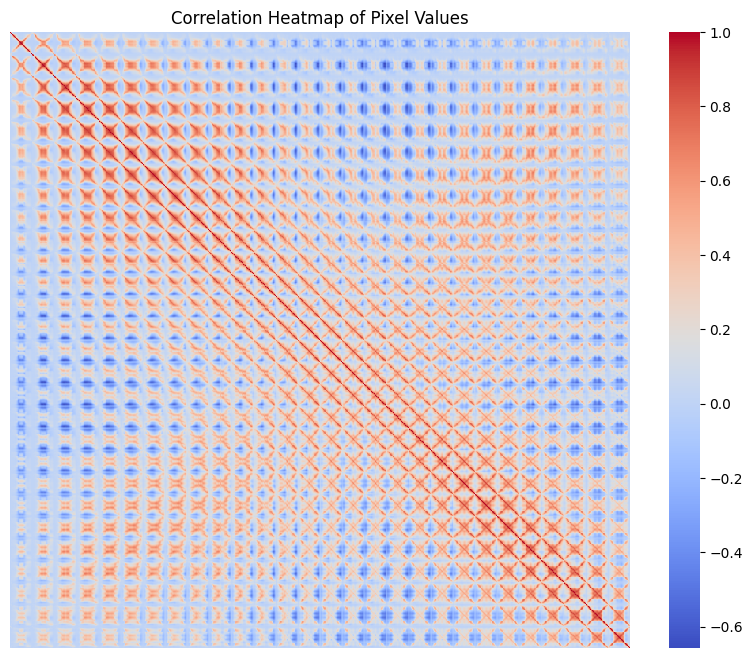

In [12]:
import torch
from torchvision import datasets, transforms
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define a transform with normalization for visualization
visualization_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load a sample of the Fashion MNIST dataset without normalization
sample_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)

# Concatenate all images into a single tensor
all_images = torch.cat([img.unsqueeze(0) for img, label in sample_dataset], dim=0)

# Reshape the tensor to have samples along the first dimension
reshaped_images = all_images.view(all_images.size(0), -1)

# Calculate the correlation matrix
correlation_matrix = np.corrcoef(reshaped_images.numpy(), rowvar=False)

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title('Correlation Heatmap of Pixel Values')
plt.show()


4.5

Visual Inspection for Anomalies:

By visually inspecting the sample images, anomalies or irregularities may become apparent. These could include:

    Noise: Random variations or disturbances in pixel values.
    Artifacts: Unintended patterns or features in the images.
    Irregularities: Deviations from the expected appearance of fashion items.

Impact on Model Performance:

Anomalies, noise, or artifacts in the images can potentially impact model performance in various ways:

    Training Difficulty: Models may struggle to learn meaningful patterns if there is substantial noise or unwanted artifacts.
    Generalization Issues: Anomalies in the training set may hinder the model's ability to generalize to unseen data.
    Robustness Challenges: Models may become sensitive to irregularities, leading to poor performance on real-world data.

Data Preprocessing Considerations:

If significant anomalies are identified, further preprocessing steps may be necessary, such as data cleaning, augmentation, or filtering, to enhance the quality of the dataset.


#1.Setup Visualization Subplots:
    Create a subplot grid with one row and five columns (1x5) for visualizing five sample images.
    The total figure size is set to (10, 6) inches.

#2.Visualize Sample Images:
Iterate over five random samples from the dataset.
For each sample:
    img contains the image tensor, and label contains the class label.
    img.squeeze().numpy() converts the image tensor to a NumPy array and removes singleton dimensions.
    axes[i].imshow(...) displays the image in the i-th subplot.
    axes[i].set_title(...) sets the title with the class label.
    axes[i].axis('off') removes axis ticks and labels for cleaner visualization.



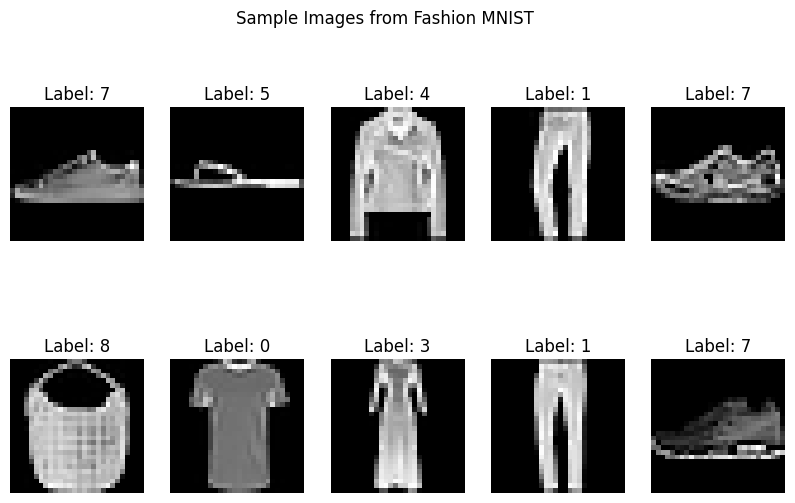

In [17]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random

# Define a transform with normalization for visualization
visualization_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
# Load a sample of the Fashion MNIST dataset without normalization
sample_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)

# Visualize a few sample images
#1
fig, axes = plt.subplots(2, 5, figsize=(10, 6))
fig.suptitle('Sample Images from Fashion MNIST')
#2
for i in range(2):
    for j in range(5):
        img, label = random.choice(sample_dataset)
        axes[i, j].imshow(img.squeeze().numpy(), cmap='gray')
        axes[i, j].set_title(f"Label: {label}")
        axes[i, j].axis('off')

plt.show()

4.6

Feature engineering is a crucial step in enhancing the performance of machine learning models. For image data, there are various techniques to extract additional features beyond raw pixel values. Here are some possibilities for feature engineering with image data, particularly focusing on Fashion MNIST:

Histogram of Oriented Gradients (HOG):

Compute HOG features to capture information about the distribution of gradients in different parts of the image. HOG is often used for object detection and can provide texture-related information.

Edge Detection:
    Apply edge detection algorithms, such as the Sobel operator or Canny edge detector, to highlight boundaries and contours in the images. Edges can be valuable features for distinguishing between different fashion items.

        Highlighting Boundaries and Contours:
            Edge detection algorithms identify significant changes in intensity or color within an image. In the context of fashion items, edges often correspond to the boundaries and contours of different clothing articles

        Feature Extraction:
            Edges represent important features in an image that can be extracted and used for further analysis. By focusing on the key contours, the model can learn patterns associated with specific shapes and structures.

        Shape Information:
            The shape of clothing items, such as the silhouette of a shoe or the outline of a dress, can be crucial for distinguishing between different classes in a classification task. Edge detection helps capture this shape information
        
        Reducing Dimensionality:
            Edge-detected images typically have fewer features than the original images, reducing the dimensionality of the data. This can be advantageous for training models, especially when working with limited computational resources.
        
        Robustness to Illumination Changes:
            Edge features are often more robust to changes in illumination compared to pixel values. By focusing on edges, the model may become less sensitive to variations in lighting conditions.
        
        Enhancing Model Generalization:
            The edges extracted from images can provide more generalized and abstract representations of the underlying structure. This can lead to improved generalization performance when the model is applied to unseen data.
        
        Improving Computational Efficiency:
            Edge detection can be computationally less expensive than working with raw pixel values, making it more efficient for processing and training machine learning models.
        
        

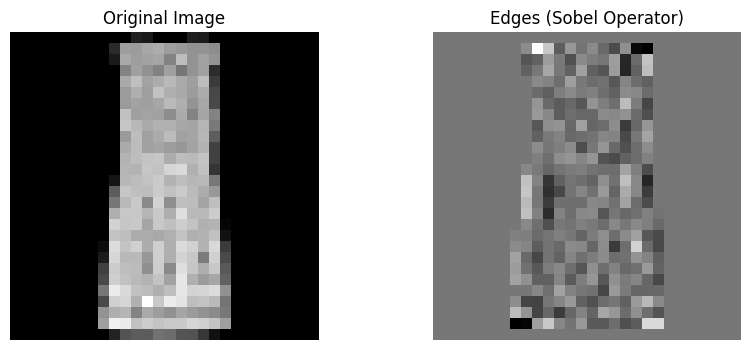

In [18]:
import cv2
import matplotlib.pyplot as plt

# Load a sample image
img, _ = random.choice(sample_dataset)

# Convert to a NumPy array
img_np = img.squeeze().numpy()

# Apply Sobel edge detection
edges = cv2.Sobel(img_np, cv2.CV_64F, 1, 1, ksize=3)

# Display original and edges
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_np, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Edges (Sobel Operator)')
plt.axis('off')

plt.show()


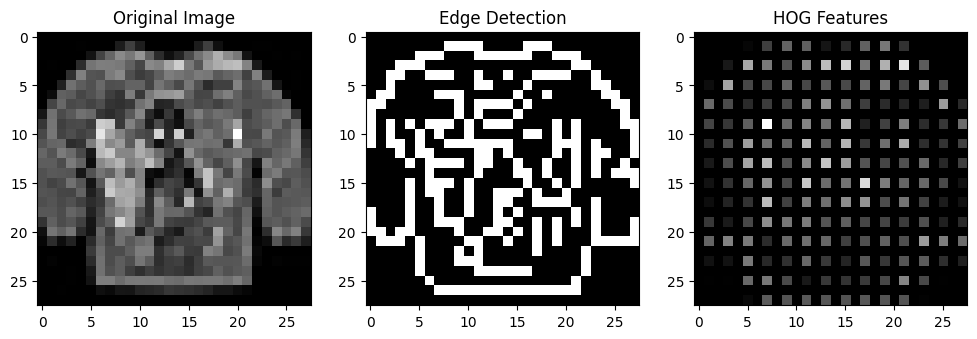

In [19]:
import cv2
import numpy as np
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Define a transform with normalization for visualization
visualization_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load a sample of the Fashion MNIST dataset without normalization
sample_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)

# Choose a random image from the dataset
random_image, label = sample_dataset[np.random.randint(0, len(sample_dataset))]

# Convert the PyTorch tensor to a NumPy array
image_np = random_image.numpy()

# Apply edge detection using the Canny edge detector
edges = cv2.Canny((image_np[0] * 255).astype(np.uint8), 50, 150)

# Extract HOG features
fd, hog_image = hog(image_np[0], orientations=8, pixels_per_cell=(2, 2), cells_per_block=(1, 1), visualize=True)

# Plot the original image, edges, and HOG features
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image_np[0], cmap='gray')
axes[0].set_title('Original Image')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Edge Detection')

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
axes[2].imshow(hog_image_rescaled, cmap='gray')
axes[2].set_title('HOG Features')

plt.show()


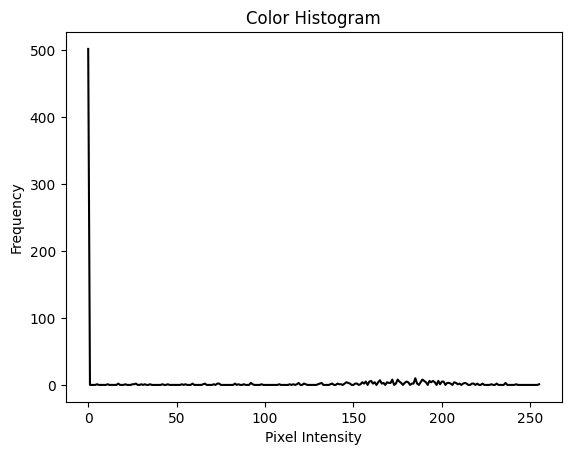

In [20]:
# Convert the image to uint8 format
img_uint8 = (img_np * 255).astype(np.uint8)

# Compute color histogram
hist, bins = np.histogram(img_uint8.flatten(), bins=256, range=[0, 256])

# Display color histogram
plt.plot(hist, color='black')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Color Histogram')
plt.show()


4.7

Define Data Augmentation Transform:
    augmentation_transform is defined as a composition of various data augmentation techniques using transforms.Compose.
    RandomHorizontalFlip(): Randomly flips the image horizontally.
    RandomVerticalFlip(): Randomly flips the image vertically.
    RandomRotation(30): Randomly rotates the image by up to 30 degrees.
    ColorJitter(...): Randomly adjusts brightness, contrast, saturation, and hue of the image.
    ToTensor(): Converts the image to a PyTorch tensor.
    Normalize((0.5,), (0.5,)): Normalizes pixel values to the range [-1, 1].

Load Augmented Dataset:
    The Fashion MNIST dataset is loaded with the specified data augmentation transform (augmentation_transform).

Visualize Original and Augmented Images:
    A 2x5 grid is created to visualize original and augmented images side by side.
    For each column:
    An original image is randomly selected from the augmented dataset.
    An augmented image is randomly selected from the augmented dataset.
    Images are displayed with their corresponding labels.
    Axes are turned off for better visualization.

Data Augmentation Transform:
    The augmentation_transform is defined as a composition of several data augmentation techniques using PyTorch's transforms.Compose. These techniques include horizontal and vertical flips, random rotations, and color jittering.

Loading Augmented Dataset:
    The Fashion MNIST dataset is loaded with the specified data augmentation transform. This means that each time an image is retrieved from this dataset during training, it undergoes a random combination of the specified transformations.

Visualizing Original and Augmented Images:
    A subplot with two rows and five columns is created to display original and augmented images side by side.
    
    For each column:
    An original image is randomly selected from the augmented dataset.
    An augmented image is randomly selected from the augmented dataset.
    Both images are displayed along with their corresponding labels.

Impact on Image Variations:
    By visualizing both original and augmented images, you can observe the impact of data augmentation on introducing variations. This variation includes changes in orientation, flips, and color adjustments.
    Augmented images are not exact replicas of the original ones, which exposes the model to a more diverse set of training examples.
    This increased diversity helps the model generalize better to new, unseen images by learning more invariant features.

 data augmentation is a powerful technique that enhances the robustness and generalization of machine learning models, particularly in scenarios with limited training data. The visualizations provide an intuitive understanding of how the dataset's diversity is expanded through these augmentation techniques.

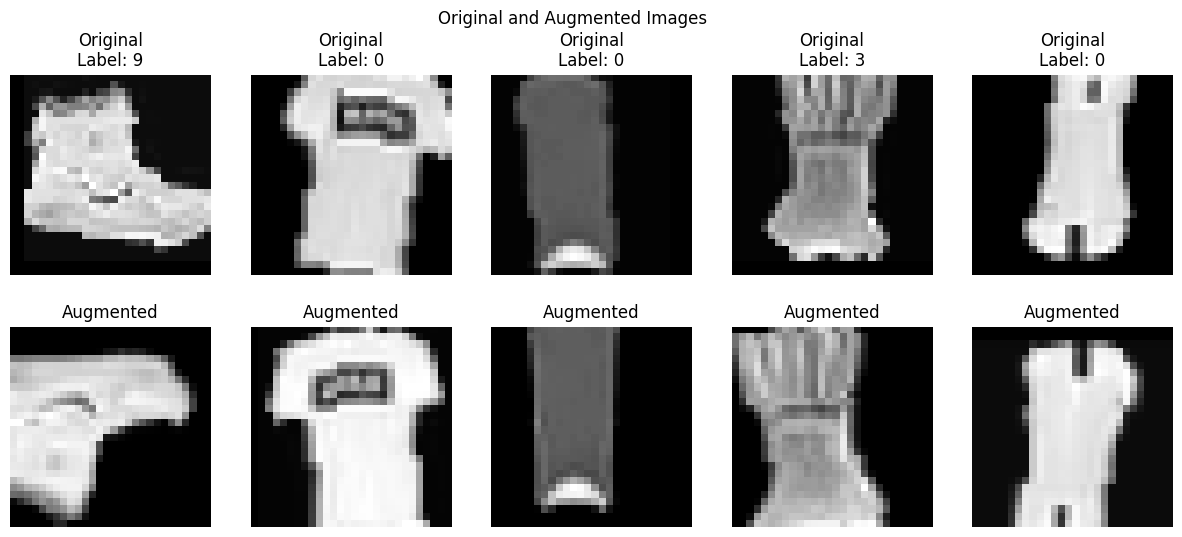

In [21]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Define data augmentation transformations
augmentation_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(28, scale=(0.8, 1.0), ratio=(0.9, 1.1))
])

# Load the Fashion MNIST dataset
train_dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=augmentation_transform)

# Visualize a few original and augmented images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Original and Augmented Images')

for i in range(5):
    original_img, label = train_dataset[i]
    augmented_img, _ = train_dataset[i]

    axes[0, i].imshow(np.array(original_img), cmap='gray')  # Convert PIL Image to NumPy array
    axes[0, i].set_title(f"Original\nLabel: {label}")
    axes[0, i].axis('off')

    axes[1, i].imshow(np.array(augmented_img), cmap='gray')  # Convert PIL Image to NumPy array
    axes[1, i].set_title("Augmented")
    axes[1, i].axis('off')

plt.show()

4.8

Implications from Exploratory Data Analysis (EDA) on MLP Model Design:

1.Class Imbalance:

If the EDA reveals significant class imbalance in the dataset (varying counts among different classes), it may impact the MLP model's performance. Strategies like class weighting or oversampling the minority class can be considered during model training to address this imbalance.

2.Pixel Value Distribution:

Understanding the distribution of pixel values helps determine whether normalization is necessary. If there are variations in pixel intensities across images, normalization (scaling pixel values to a certain range) can be beneficial for model convergence and stability.

3.Feature Engineering:

EDA might highlight specific features or patterns in the images that can be leveraged for better model performance. For instance, if edges or textures play a crucial role, incorporating edge detection or texture analysis as additional features could be explored.

4.Anomalies or Irregularities:

If anomalies or irregularities are identified in the images, such as artifacts or noise, preprocessing steps like denoising or removing outliers may be considered to improve model robustness.

5.Correlation Analysis:

Understanding pixel correlation can guide feature selection. Features with high correlation may not contribute significantly to model learning and could potentially be reduced or combined.

Data Augmentation:

EDA might reveal the need for data augmentation. If there's limited diversity in the training set, augmenting the data with transformations like flips, rotations, and color adjustments can be crucial to enhance the model's ability to generalize.


Preprocessing Steps Based on EDA:

1.Normalization:

If pixel values show a wide range of intensities across images, normalization (scaling to a specific range) can be applied to ensure consistent input for the MLP model.

2.Data Augmentation:

If EDA indicates a lack of diversity in the dataset, data augmentation can be employed during training to introduce variations and improve the model's ability to handle different image conditions.

3.Feature Engineering:

Based on EDA insights, additional features derived from edge detection, texture analysis, or other techniques can be incorporated to enhance the model's ability to capture relevant patterns.

4.Handling Class Imbalance:

If class imbalance is identified, techniques such as class weighting, oversampling, or undersampling can be applied to address the imbalance and prevent the model from being biased toward the majority class.

5.Noise Reduction:

If noise or irregularities are present in the images, preprocessing steps like denoising filters or outlier removal can be considered to clean the data before training.


findings from EDA inform crucial decisions in the design and preprocessing of the MLP model. Tailoring the model architecture and preprocessing steps based on a comprehensive understanding of the dataset characteristics can significantly impact the model's performance and generalization ability.
